These simulations are based on lecture note and exercises from Complex Physics course by Kim Sneppen (KU)

## The Stock market
    The stock market refers to the collection of markets and exchanges where regular activities of buying, 
    selling, and issuance of shares of publicly-held companies take place. (Investopedia)

If one could predict the stock market, one would surely make a profit .. unfortunately that is an ancient dream as such market is almost unpredictable!

## The stock market approximately exhibits a biased random walk in $log(price)$

we define this log quantity as, $s$:

         s(t) = log(v(t)) 

where the price, $v$, is of course a function that changes in time, $t$

In theory, a random walk has a dependent variable that is proportional to an independent variable to the power of $0.5$ :

        W (T ) ∝ T^{0.5}
  
In this case $T$ is a time interval


In [3]:
import numpy as np
from scipy import interpolate
from scipy import integrate
from tqdm import tqdm
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

To simulate a stock market as a 'biased' random walk, 
We take additional probability, $p$, as the probability of the price continuing in the same direction as the previous step

( so a biased random walk is a random walk that is trending in a direction i.e. increasing)

In [68]:
v = []

def Stock(nmax,P):
    price = 0 
    step = np.random.choice((-1,1),1 )   # pick whether first step go down 1 or up 1
    #print('initial price=',step)
    v.append(price)
    v.append(step)
    
    for i in range (nmax):               #  time steps
        
            newprice = price + step * np.random.choice((-1,1),1,p=[1-P,P] )  
                                    # x 1 = same direction 
                                    # x -1 = opposite direction
            step = np.random.choice((-1,1),1 )
            price = newprice
            v.append(price)        
    return v


timemax = 100
V = Stock(timemax,0.75)
t = np.linspace(0,timemax,len(V),dtype=object)

/Users/kam/opt/anaconda3/lib/python3.9/site-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


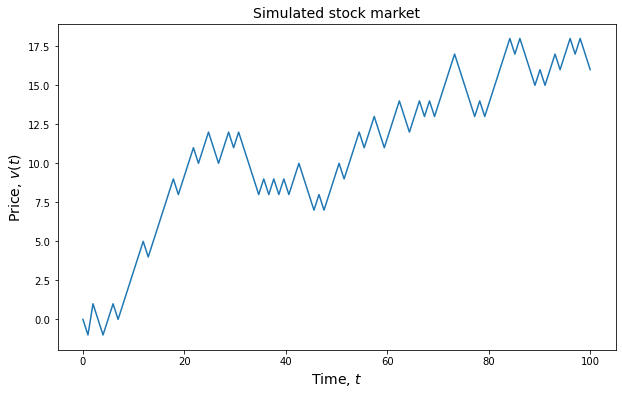

In [69]:
plt.figure(figsize=(10,6))
plt.title('Simulated stock market',fontsize='14')
plt.xlabel(r'Time, $t$',fontsize='14')
plt.ylabel(r'Price, $v(t)$',fontsize='14')
plt.plot( t,V)
plt.show()

## Hurst exponent
Is is true that it's nearly impossible to predict the stock market, but one can at least try .. to define correlation between the past and future.

Let's express the price difference between present time, $x$, and the future at a time, $T$, So we have : ∆s(T) = s(T + $x$) − s($x$)

And price varation time $-T$ into the past : ∆s(−T ) = s(x − T ) − s(x)

The correlation is then :
\begin{equation}
C ≡ \frac{⟨(s(t) − s(t − T)) · (s(t + T) − s(t))⟩_t  }{ ⟨(∆s(T))^2 ⟩_t}
\end{equation}

Here we can express the denominator as **'variance over time interval T'** :
\begin{equation}
f(T) = ⟨(∆s(T))^2 ⟩_t
\end{equation}

And the numerator as
\begin{equation}
⟨−∆s(−T )∆s(T )⟩t = \frac{1}{2} f(2T)−f(T)
\end{equation}

Using some maths trick that I will not write fully here.
We can also rewrite $f(T)$ by assuming that average of samples are taken over a long enough time ..
\begin{equation}
f(T) \propto T^{2H}
\end{equation}

Therefore,
\begin{equation}
C = \frac{⟨−∆s(−T) · ∆s(T)⟩_t}{⟨(∆s(T))^2 ⟩_t} =  2^{2H−1} − 1
\end{equation}

### **Interpretation:**

In an ordinary random walk, there is no correlation between future and the past; $C=0$ and so H = 1/2

Where $H> 1/2 $, the price progression should be in the same direction. I.e. if the price increased during the past month, then it will, also on averageg increase during the next month.

In contrast, if $H< 1/2$ market the price fluctuations will tend to revert.

This means that, as long as the 'random walk' os characterised by $H$, one could use this interpretaion to devise a buy-sell strategy to gain profit

    Now we will calculate, $H$ from the stock market simulation from previously, by averaging the variance over larger and larger time steps. 
    I.e. : one hundred simulated time-series of length 100, hundred time-series of length 1,000, and hundred timeseries of length 10,000.

In [70]:
s = []

def Hurst(nmax,P):
    price = 0 
    
    for j in tqdm(range(100)):              # average over 100 simukations
        step = np.random.choice((-1,1),1 ) 
        for i in range (nmax):              # nmax time steps
            
            newprice = price + step * np.random.choice((-1,1),1,p=[1-P,P] )  
            step = np.random.choice((-1,1),1 )
            price = newprice
    
        s.append(price**2)                  # variance of each end points
    return np.mean(s)
Hurst = np.vectorize(Hurst)

In [71]:
T = np.array([100,1000,10000])       # time steps
Hurst(T,0.75)

100%|█████████████████████████████████████████| 100/100 [01:15<00:00,  1.33it/s]


array([ 9669.5 , 21025.28, 27765.28])

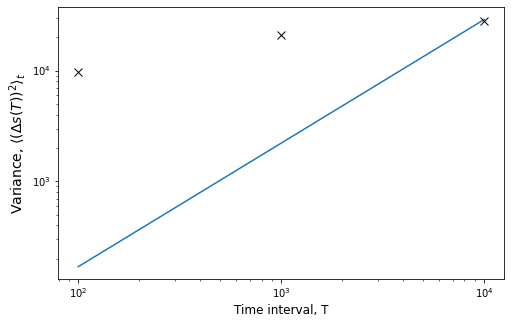

Hurst exponent =  [0.55756612]


In [79]:
W2mean = np.array([ 9669.5 , 21025.28, 27765.28])

def func(x,m):
    return x**m   
popt, pcov  = curve_fit(func,T,W2mean )

plt.figure(figsize=(8,5))
plt.loglog()

plt.xlabel('Time interval, T',fontsize='12')
plt.ylabel('Variance, '+r'$⟨(∆s(T))^2 ⟩_t$',fontsize='14')
plt.plot( T ,func(T,*popt) )
plt.plot(T,W2mean,'x',color='black',markersize='8')
plt.show()

print('Hurst exponent = ',popt/2) #, 'pcov', pcov 

In [80]:
Hurst(T,0.99)

100%|█████████████████████████████████████████| 100/100 [01:32<00:00,  1.08it/s]


array([19669.34 , 18322.36 , 21932.405])